<a href="https://colab.research.google.com/github/Talat30/ObjectDetection-EndSem/blob/main/obj_endSem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

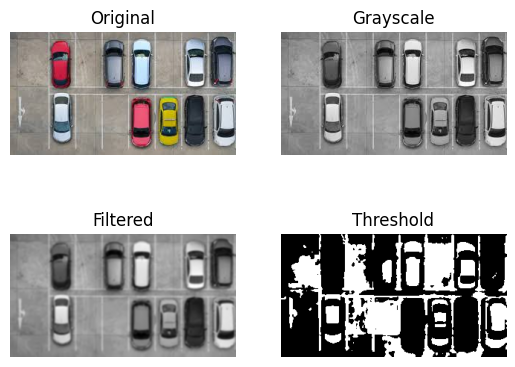

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/sample_data/parking_image.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
_, thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)


plt.subplot(2,2,1); plt.imshow(img); plt.title("Original"); plt.axis('off')
plt.subplot(2,2,2); plt.imshow(gray, cmap='gray'); plt.title("Grayscale"); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(blur, cmap='gray'); plt.title("Filtered"); plt.axis('off')
plt.subplot(2,2,4); plt.imshow(thresh, cmap='gray'); plt.title("Threshold"); plt.axis('off')

plt.show()

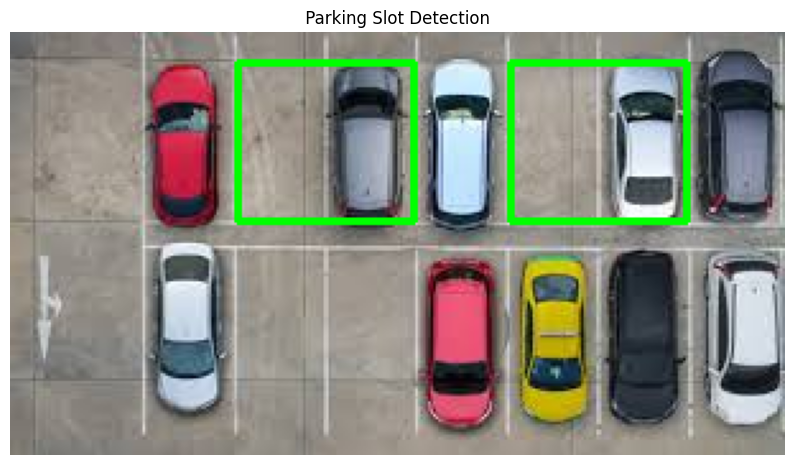

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# load image
img = cv2.imread('/content/sample_data/parking_image.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# edge detection
edges = cv2.Canny(gray, 50, 150)

# detect lines
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100,
                        minLineLength=100, maxLineGap=10)

vertical = []
horizontal = []

# separate vertical & horizontal lines
for line in lines:
    x1,y1,x2,y2 = line[0]

    if abs(x1-x2) < 10:
        vertical.append(x1)
    elif abs(y1-y2) < 10:
        horizontal.append(y1)

# sort & remove duplicates
vertical = sorted(set(vertical))
horizontal = sorted(set(horizontal))

# draw grid boxes
for i in range(len(vertical)-1):
    for j in range(len(horizontal)-1):
        x1 = vertical[i]
        x2 = vertical[i+1]
        y1 = horizontal[j]
        y2 = horizontal[j+1]

        # filter small/noise boxes
        if (x2-x1) > 50 and (y2-y1) > 50:
            cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (0,255,0), 2)

# display
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title(" Parking Slot Detection ")
plt.axis('off')
plt.show()

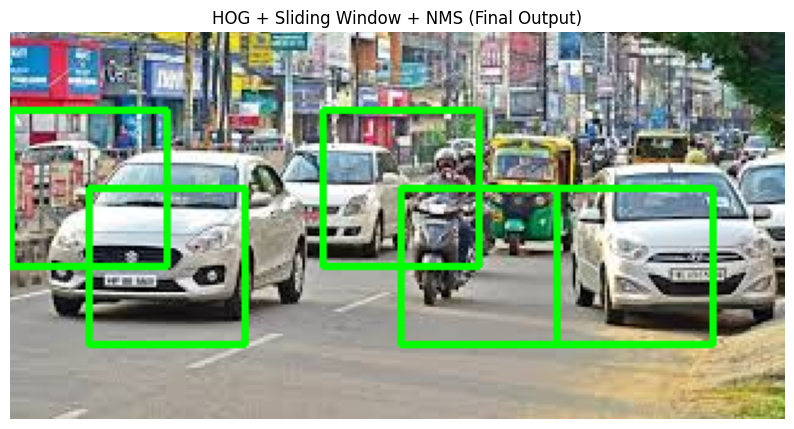

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import LinearSVC

# -----------------------------
# STEP 1: HOG feature function
# -----------------------------
def extract_hog(img):
    return hog(img, pixels_per_cell=(8,8),
               cells_per_block=(2,2), visualize=False)

# -----------------------------
# STEP 2: Load image
# -----------------------------
img = cv2.imread('/content/sample_data/vehicle.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# -----------------------------
# STEP 3: Train simple SVM (demo)
# -----------------------------
X = []
y = []

h, w = gray.shape

# positive sample (center region)
# This is a simplified training for demonstration purposes.
# For real-world accuracy, a proper dataset and training are needed.
center = gray[h//4:3*h//4, w//4:3*h//4]
center = cv2.resize(center, (64,64))
X.append(extract_hog(center))
y.append(1)

# negative sample (corner)
corner = gray[0:64, 0:64]
X.append(extract_hog(corner))
y.append(0)

model = LinearSVC()
model.fit(X, y)

# -----------------------------
# STEP 4: Sliding window
# -----------------------------
def sliding_window(image, step, ws):
    for y in range(0, image.shape[0] - ws[1] + 1, step):
        for x in range(0, image.shape[1] - ws[0] + 1, step):
            yield (x, y, image[y:y+ws[1], x:x+ws[0]])

window_size = (64,64)
step_size = 32

boxes = []

# -----------------------------
# STEP 5: Detection
# -----------------------------
for (x, y, window) in sliding_window(gray, step_size, window_size):
    if window.shape[0] != window_size[1] or window.shape[1] != window_size[0]:
        continue

    features = extract_hog(window)
    pred = model.predict([features])

    if pred == 1:
        boxes.append([x, y, x+window_size[0], y+window_size[1]])

# -----------------------------
# STEP 6: Non-Max Suppression
# -----------------------------
def non_max_suppression(boxes, overlapThresh=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]

    area = (x2 - x1) * (y2 - y1)
    idxs = np.argsort(y2)

    pick = []

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)

        xx1 = np.maximum(x1[last], x1[idxs[:-1]])
        yy1 = np.maximum(y1[last], y1[idxs[:-1]])
        xx2 = np.minimum(x2[last], x2[idxs[:-1]])
        yy2 = np.minimum(y2[last], y2[idxs[:-1]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        overlap = (w * h) / area[idxs[:-1]]

        idxs = idxs[np.where(overlap <= overlapThresh)]

    return boxes[pick]

final_boxes = non_max_suppression(boxes)

# -----------------------------
# STEP 7: Draw final boxes
# -----------------------------
for (x1,y1,x2,y2) in final_boxes:
    cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (0,255,0), 2)

# -----------------------------
# STEP 8: Display
# -----------------------------
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("HOG + Sliding Window + NMS (Final Output)")
plt.axis('off')
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 448x640 3 cars, 10 cell phones, 354.2ms
Speed: 9.2ms preprocess, 354.2ms inference, 47.0ms postprocess per image at shape (1, 3, 448, 640)


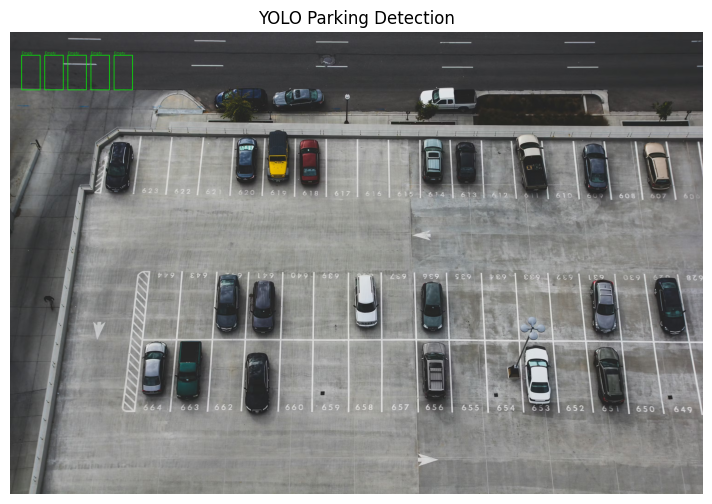

In [51]:
!pip install ultralytics




0: 448x640 3 cars, 10 cell phones, 272.8ms
Speed: 13.9ms preprocess, 272.8ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)


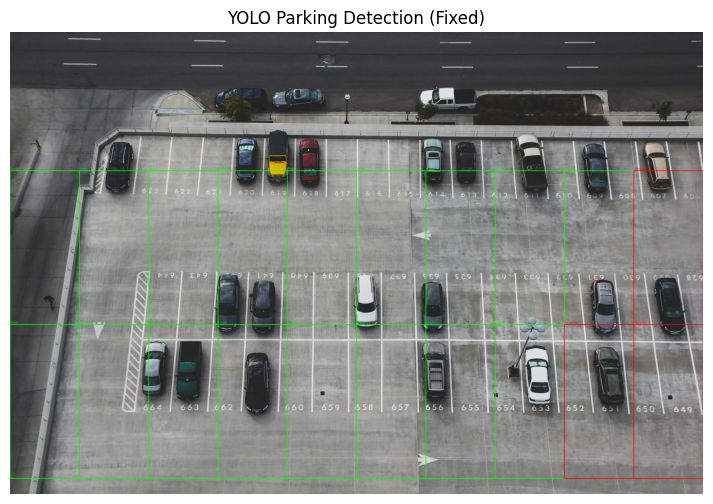

In [52]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# load model
model = YOLO('yolov8n.pt')

# load image
img = cv2.imread('/content/sample_data/parking.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

# -----------------------------
# Create grid slots automatically
# -----------------------------
rows = 2
cols = 10

slot_w = w // cols
slot_h = h // (rows + 1)   # ignore road area

slots = []

for r in range(rows):
    for c in range(cols):
        x = c * slot_w
        y = int(h*0.3) + r * slot_h   # shift to parking area
        slots.append((x, y, slot_w, slot_h))

# initialize
status = ["Empty"] * len(slots)

# -----------------------------
# YOLO detection
# -----------------------------
results = model(img)[0]

# -----------------------------
# Check overlap
# -----------------------------
for box in results.boxes:
    cls = int(box.cls[0])

    # filter only vehicles
    if cls not in [2, 3, 5, 7]:  # car, bike, bus, truck
        continue

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    for i, (sx, sy, sw, sh) in enumerate(slots):
        if (x1 < sx+sw and x2 > sx and y1 < sy+sh and y2 > sy):
            status[i] = "Occupied"

# -----------------------------
# Draw results
# -----------------------------
for i, (x,y,w,h) in enumerate(slots):
    color = (0,255,0) if status[i]=="Empty" else (255,0,0)

    cv2.rectangle(img_rgb, (x,y), (x+w,y+h), color, 2)
    cv2.putText(img_rgb, status[i], (x,y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

# display
plt.figure(figsize=(12,6))
plt.imshow(img_rgb)
plt.title("YOLO Parking Detection (Fixed)")
plt.axis('off')
plt.show()


0: 448x640 3 cars, 10 cell phones, 336.0ms
Speed: 6.0ms preprocess, 336.0ms inference, 3.2ms postprocess per image at shape (1, 3, 448, 640)
IoU: 0.0
Precision: 0.0
Recall: 0.0


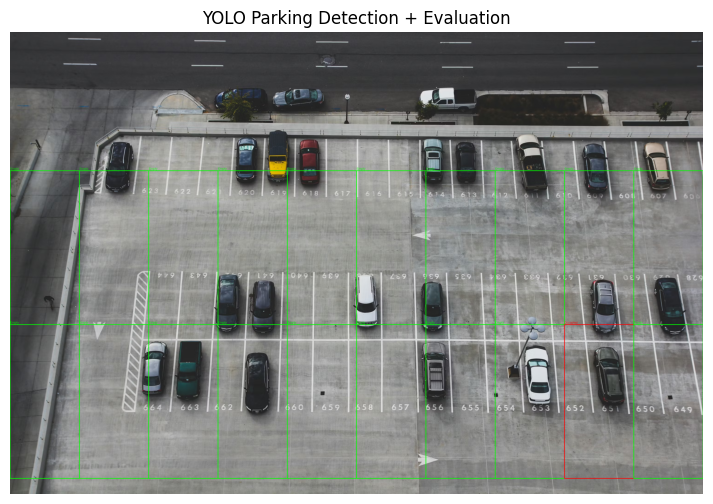

In [58]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# Load YOLO model
# -----------------------------
model = YOLO('yolov8n.pt')

# -----------------------------
# Load image
# -----------------------------
img = cv2.imread('/content/sample_data/parking.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

H, W, _ = img.shape

# -----------------------------
# Create parking slots (grid)
# -----------------------------
rows = 2
cols = 10

slot_w = W // cols
slot_h = H // (rows + 1)

slots = []
for r in range(rows):
    for c in range(cols):
        x1 = c * slot_w
        y1 = int(H * 0.3) + r * slot_h
        x2 = x1 + slot_w
        y2 = y1 + slot_h
        slots.append((x1, y1, x2, y2))

# -----------------------------
# Initialize predictions
# -----------------------------
status = ["Empty"] * len(slots)

# -----------------------------
# YOLO Detection
# -----------------------------
results = model(img)[0]

vehicle_boxes = []

for box in results.boxes:
    cls = int(box.cls[0])

    # vehicle classes: car, bike, bus, truck
    if cls in [2, 3, 5, 7]:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        vehicle_boxes.append((x1, y1, x2, y2))

# -----------------------------
# IoU function
# -----------------------------
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)

# -----------------------------
# Assign occupancy using IoU
# -----------------------------
for i, slot in enumerate(slots):
    for vbox in vehicle_boxes:
        if compute_iou(slot, vbox) > 0.15:
            status[i] = "Occupied"
            break

# -----------------------------
# Convert predictions
# -----------------------------
predictions = [1 if s == "Occupied" else 0 for s in status]

# -----------------------------
# Ground Truth (MANUAL - change this)
# -----------------------------
ground_truth = [1,1,0,0,1,0,1,0,0,1,
                1,0,0,1,0,0,1,1,0,0]

# -----------------------------
# Evaluation Metrics
# -----------------------------
tp = fp = fn = 0
intersection = union = 0

for gt, pred in zip(ground_truth, predictions):

    # IoU (binary occupancy)
    if gt == 1 and pred == 1:
        intersection += 1
    if gt == 1 or pred == 1:
        union += 1

    # Precision / Recall
    if pred == 1 and gt == 1:
        tp += 1
    elif pred == 1 and gt == 0:
        fp += 1
    elif pred == 0 and gt == 1:
        fn += 1

iou_score = intersection / (union + 1e-6)
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)

print("IoU:", round(iou_score, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))

# -----------------------------
# Draw results
# -----------------------------
for i, (x1, y1, x2, y2) in enumerate(slots):
    color = (0,255,0) if status[i]=="Empty" else (255,0,0)

    cv2.rectangle(img_rgb, (x1,y1), (x2,y2), color, 2)
    cv2.putText(img_rgb, status[i], (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

# -----------------------------
# Show output
# -----------------------------
plt.figure(figsize=(12,6))
plt.imshow(img_rgb)
plt.title("YOLO Parking Detection + Evaluation")
plt.axis('off')
plt.show()

In [59]:
import numpy as np

# -----------------------------
# Image Augmentation (conditions)
# -----------------------------
def low_light(img):
    return cv2.convertScaleAbs(img, alpha=0.5, beta=-30)

def bright_light(img):
    return cv2.convertScaleAbs(img, alpha=1.5, beta=40)

def fog(img):
    fog_layer = np.full_like(img, 200)
    return cv2.addWeighted(img, 0.7, fog_layer, 0.3, 0)

def rain_blur(img):
    return cv2.GaussianBlur(img, (7,7), 0)

# store conditions
conditions = {
    "Normal": img,
    "Low Light": low_light(img),
    "Bright": bright_light(img),
    "Fog": fog(img),
    "Rain/Blur": rain_blur(img)
}

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate_image(test_img):

    results = model(test_img)[0]

    vehicle_boxes = []
    for box in results.boxes:
        cls = int(box.cls[0])
        if cls in [2,3,5,7]:
            x1,y1,x2,y2 = map(int, box.xyxy[0])
            vehicle_boxes.append((x1,y1,x2,y2))

    status = ["Empty"] * len(slots)

    for i, slot in enumerate(slots):
        for vbox in vehicle_boxes:
            if compute_iou(slot, vbox) > 0.15:
                status[i] = "Occupied"
                break

    preds = [1 if s=="Occupied" else 0 for s in status]

    # metrics
    tp = fp = fn = 0
    inter = union = 0

    for gt, pr in zip(ground_truth, preds):
        if gt==1 and pr==1:
            inter += 1
        if gt==1 or pr==1:
            union += 1

        if pr==1 and gt==1:
            tp+=1
        elif pr==1 and gt==0:
            fp+=1
        elif pr==0 and gt==1:
            fn+=1

    iou = inter/(union+1e-6)
    precision = tp/(tp+fp+1e-6)
    recall = tp/(tp+fn+1e-6)

    return iou, precision, recall

# -----------------------------
# Run for all conditions
# -----------------------------
for name, test_img in conditions.items():
    iou, precision, recall = evaluate_image(test_img)
    print(f"{name} -> IoU: {iou:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")


0: 448x640 3 cars, 10 cell phones, 192.7ms
Speed: 5.4ms preprocess, 192.7ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)
Normal -> IoU: 0.000, Precision: 0.000, Recall: 0.000

0: 448x640 9 cell phones, 233.4ms
Speed: 6.7ms preprocess, 233.4ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
Low Light -> IoU: 0.000, Precision: 0.000, Recall: 0.000

0: 448x640 1 car, 1 bus, 1 truck, 8 cell phones, 485.2ms
Speed: 15.8ms preprocess, 485.2ms inference, 6.2ms postprocess per image at shape (1, 3, 448, 640)
Bright -> IoU: 0.000, Precision: 0.000, Recall: 0.000

0: 448x640 3 cell phones, 818.4ms
Speed: 17.8ms preprocess, 818.4ms inference, 4.7ms postprocess per image at shape (1, 3, 448, 640)
Fog -> IoU: 0.000, Precision: 0.000, Recall: 0.000

0: 448x640 8 cell phones, 1025.4ms
Speed: 10.1ms preprocess, 1025.4ms inference, 6.7ms postprocess per image at shape (1, 3, 448, 640)
Rain/Blur -> IoU: 0.000, Precision: 0.000, Recall: 0.000
